[2.231499907401901, 1.456862718169367, 1.8294640678379566, 2.9416086117105715]
[[1.  0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0. ]
 [0.  0.  0.  0.1]]


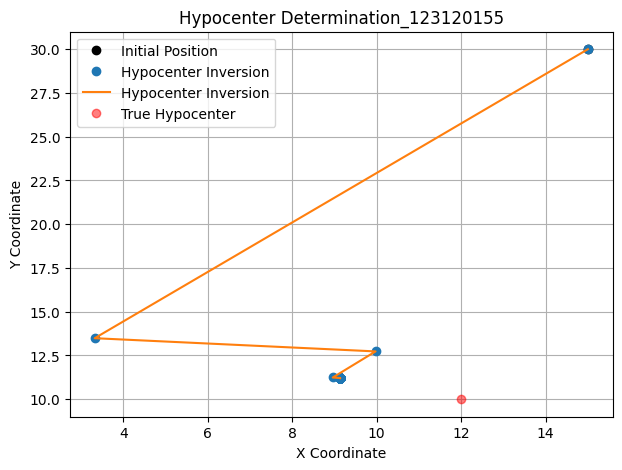

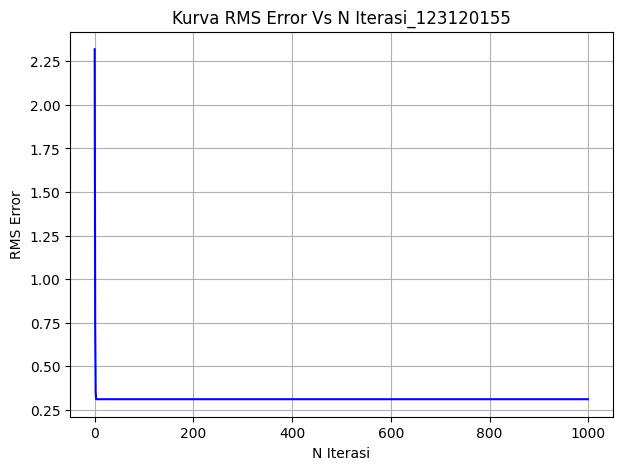

In [1]:
import numpy as np                  #import library numpy untuk operasi matematis
import matplotlib.pyplot as plt     #import library matplotlib untuk memvisualisasikan grafik
import copy                         #import library copy untuk menyalin secara independen
from numpy.linalg import inv        #dari numpy untuk import fungsi invers matriks

#station Position
x =[0, 10, 20, 30]  #menyatakan posisi horizontal (x) setiap stasiun
z = [0, 0, 0, 0]    #menyatakan posisi vertikal (y) setiap stasiun
n = len (x)         #jumlah stasiun

#true hiposenter
x0 = 12     #posisi x hiposenter sebenarnya
z0 = 10     #posisi y hiposenter sebenarnya
t0 = 0      #waktu origin gempa

#model velocity 1 layer
v = 7       #kecepatan gelombang

#forward modelling to calculate traveltime from hyposenter to station
t = []                                                          #list untuk menyimpan t
for i in range(n):
    t.append((1/v) * np.sqrt((z[i] -z0)**2 + (x[i] - x0)**2))   #menghitung traveltime tiap stasiun

#add noise to traveltime data
noise = np.random.rand(n)*0.03*np.mean(t)   #memunculkan noise random 0.03 ke data timetravel
ti = t + noise                              #menambahkan noise ke t

print(t)                                    #menampilkan t

#add outlier data
ti[n-1] = ((1/v) * np.sqrt((z[n-1] - z0)**2 + (x[n-1] - x0)**2)) + np.random.rand()*0.5*np.mean(t)
#mengganti data stasiun terakhir dengan nilai outlier

#guess the initial position
M = [15, 30]                        #tebakan awal posisi hiposenter
init_position = copy.deepcopy(M)    #menyalin posisi awal
M1 = []                             #list kosong

#create weighted matrix
W = np.eye(n)                       #membuat weighted matrix 4x4

#assign weighted matrix
W[n-1][n-1] = 0.1                   #menambahkan bobot 0.1 pada data outlier
#W[i][i] = abs(ti[i]    (ti[i]  np.mean(ti)))

print(W)    #menampilkan weighted matrix

xhipo = [init_position[0]]      #menyimpan x  hipo tiap iterasi pada list
yhipo = [init_position[1]]      #menyimpan y  hipo tiap iterasi pada list
Erms = []                       #menyimpan nilai RMS error tiap iterasi pada list

#Inversion without weighted factor
for niter in range(1000):   #ganti jumlah iterasi sebanyak 1000x
    gm = []                 #menyimpan gm pada list
    dgm_dm1 = []            #turunan parsial terhadap parameter x kolom 1
    dgm_dm2 = []            #turunan parsial terhadap parameter y kolom 2

    for i in range(n):
        gm.append(t0 + (1/v)*(np.sqrt((x[i] - M[0])**2 + (z[i] - M[1])**2)))                        #menghitung tmodel berdasarkan posisi hipo skrg
        dgm_dm1.append((1/v) * (-1*(x[i] - M[0]))/(np.sqrt((x[i] - M[0])**2 + (z[i] - M[1])**2)))   #turunan parsial t terhadap x
        dgm_dm2.append((1/v) * (-1*(z[i] - M[1]))/(np.sqrt((x[i] - M[0])**2 + (z[i] - M[1])**2)))   #turunan parsial t terhadap z

    J = np.zeros((n, 2))            #membuat matrix jacobian 4x2

    for i in range(n):
        J[i][0] = dgm_dm1[i].item() #kolom pertama matriks jacobian terhadap x
        J[i][1] = dgm_dm2[i].item() #kolom kedua matrix jacobian terhadap z

    Mo = copy.deepcopy(M)           #menyalin model secara independen

    #add model pertubation from inv to Mo
    Mo = np.reshape(Mo, (2,1))      #mengubah Mo ke matriks kolom 2x1
    ti = np.reshape(ti, (n,1))      #mengubah ti ke matriks kolom 4x1
    gm = np.reshape(gm, (n,1))      #mengubah gm ke matriks kolom 4x1

    Model = np.mat(Mo) + np.mat(inv(np.mat(J).transpose() * np.mat(J))) * np.mat(J.transpose()) * (np.mat(ti) - np.mat(gm))     #memperbarui model menggunakan rumus gauss-newton
    M = [Model[0][0], Model[1][0]]  #mengambil x dan z sebagai model baru

    Data = Model.tolist()       #mengubah model ke list
    xhipo.append(Data[0][0])    #menyimpan xhipo hasil iterasi ke list
    yhipo.append(Data[1][0])    #menyimpan yhipo hasil iterasi ke list

    # Calculate rms error
    dt = ti - gm # (np.mat(ti) - np.mat(gm))    #menghitung selisih data observasi dan kalkulasi
    Erms.append(np.sqrt(np.average(dt**2)))     #menghitung rmse sebagai akar rata-rata kuadrat resdual  

plt.figure(figsize=(7,5))                                               
plt.plot(15, 30, 'o', label='Initial Position', color='black')          #plot posisi awal tebakan dengan warna hitam
plt.plot(xhipo, yhipo, 'o', label='Hypocenter Inversion')               #plot xhipo yhipo tiap iterasi dengan lingkaran
plt.plot(xhipo, yhipo, '-', label='Hypocenter Inversion')               #plot xhipo yhipo dengan garis
plt.plot(x0, z0, 'o', alpha=0.5, color='red', label='True Hypocenter')  #plot x0 z0 dengan warna merah sebagai hiposenter sebenarnya
plt.title('Hypocenter Determination_123120155')                               #plot judul grafik
plt.xlabel('X Coordinate')                                              #plot label sumbu x
plt.ylabel('Y Coordinate')                                              #plot label sumbu y
plt.legend()                                                            #plot legenda pada grafik
plt.grid()                                                              #plot grid

# Plot kurva error RMS terhadap iterasi
plt.figure(figsize=(7,5))                       #plot grafik 7x5 inch                   
plt.plot(Erms, color='blue')                    #plot erms dengan warna biru
plt.title('Kurva RMS Error Vs N Iterasi_123120155')   #plot judul
plt.ylabel('RMS Error')                         #plot label sumbu y
plt.xlabel('N Iterasi')                         #plot label sumbu x
plt.grid()                                      #plot grid
plt.show()                                      #menampilkan semua plot/grafik

[2.231499907401901, 1.456862718169367, 1.8294640678379566, 2.9416086117105715]
[[1.  0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0. ]
 [0.  0.  0.  0.1]]


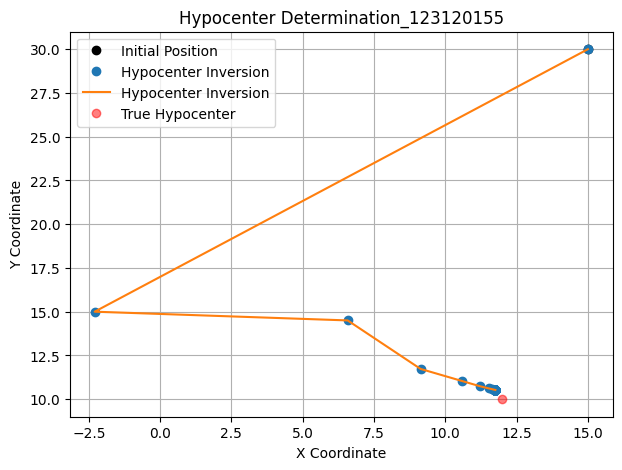

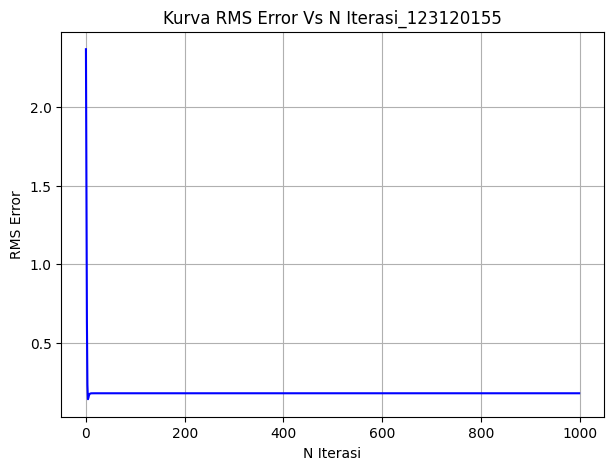

In [2]:
import numpy as np                  #import library numpy untuk operasi matematis
import matplotlib.pyplot as plt     #import library matplotlib untuk memvisualisasikan grafik
import copy                         #import library copy untuk menyalin secara independen
from numpy.linalg import inv        #dari numpy untuk import fungsi invers matriks
np.mat = np.asmatrix                #membuat alias np.mat ke np.asmatrix 

#station Position
x =[0, 10, 20, 30]  #menyatakan posisi horizontal (x) setiap stasiun
z = [0, 0, 0, 0]    #menyatakan posisi vertikal (y) setiap stasiun
n = len (x)         #jumlah stasiun

#true hiposenter
x0 = 12     #posisi x hiposenter sebenarnya
z0 = 10     #posisi y hiposenter sebenarnya
t0 = 0      #waktu origin gempa

#model velocity 1 layer
v = 7       #kecepatan gelombang

#forward modelling to calculate traveltime from hyposenter to station
t = []                                                          #list untuk menyimpan t
for i in range(n):
    t.append((1/v) * np.sqrt((z[i] -z0)**2 + (x[i] - x0)**2))   #menghitung traveltime tiap stasiun

#add noise to traveltime data
noise = np.random.rand(n)*0.03*np.mean(t)   #memunculkan noise random 0.03 ke data timetravel
ti = t + noise                              #menambahkan noise ke t

print(t)                                    #menampilkan t

#add outlier data
ti[n-1] = ((1/v) * np.sqrt((z[n-1] - z0)**2 + (x[n-1] - x0)**2)) + np.random.rand()*0.5*np.mean(t)
#mengganti data stasiun terakhir dengan nilai outlier

#guess the initial position
M = [15, 30]                        #mendefinisikan tebakan awal posisi hiposenter
init_position = copy.deepcopy(M)    #menyalin posisi awal
M1 = []                             #list kosong

#create weighted matrix
W = np.eye(n)                       #membuat weighted matrix 4x4

#assign weighted matrix
W[n-1][n-1] = 0.1                   #menambahkan bobot 0.1 pada data outlier
#W[i][i] = abs(ti[i]    (ti[i]  np.mean(ti)))

print(W)    #menampilkan weighted matrix

xhipo = [init_position[0]]          #menyimpan x  hipo tiap iterasi pada list
yhipo = [init_position[1]]          #menyimpan y  hipo tiap iterasi pada list
Erms = []                           #menyimpan nilai RMS error tiap iterasi pada list

#Inversion without weighted factor
for niter in range(1000):           #ganti jumlah iterasi sebanyak 1000x
    gm = []                         #menyimpan gm pada list
    dgm_dm1 = []                    #turunan parsial terhadap parameter x kolom 1
    dgm_dm2 = []                    #turunan parsial terhadap parameter y kolom 2

    for i in range(n):
        gm.append(t0 + (1/v)*(np.sqrt((x[i] - M[0])**2 + (z[i] - M[1])**2)))                        #menghitung tmodel berdasarkan posisi hipo skrg
        dgm_dm1.append((1/v) * (-1*(x[i] - M[0]))/(np.sqrt((x[i] - M[0])**2 + (z[i] - M[1])**2)))   #turunan parsial t terhadap x kolom pertama
        dgm_dm2.append((1/v) * (-1*(z[i] - M[1]))/(np.sqrt((x[i] - M[0])**2 + (z[i] - M[1])**2)))   #turunan parsial t terhadap z kolom kedua

    J = np.zeros((n, 2))            #membuat matrix jacobian 4x2

    for i in range(n):
        J[i][0] = dgm_dm1[i].item() #kolom pertama matriks jacobian terhadap x
        J[i][1] = dgm_dm2[i].item() #kolom kedua matrix jacobian terhadap z

    Mo = copy.deepcopy(M)           #menyalin model secara independe

   #add model pertubation from inv to Mo
    Mo = np.reshape(Mo, (2,1))      #mengubah Mo ke matriks kolom 2x1
    ti = np.reshape(ti, (n,1))      #mengubah ti ke matriks kolom 4x1
    gm = np.reshape(gm, (n,1))      #mengubah gm ke matriks kolom 4x1


    Model = np.mat(Mo) + np.mat(inv(np.mat(J).transpose() * np.mat(J))) * np.mat(J.transpose()) * np.mat(W) * (np.mat(ti) - np.mat(gm))
    #memperbarui posisi hiposenter menggunakan rumus Gauss-Newton berbobot: M_baru = M_lama + (JᵀJ)⁻¹ Jᵀ W (d_obs - d_calc)
    M = [Model[0][0], Model[1][0]]
    #mengambil nilai x dan z hasil iterasi untuk model hiposenter baru

    Data = Model.tolist()       #mengubah model ke list
    xhipo.append(Data[0][0])    #menyimpan xhipo hasil iterasi ke list
    yhipo.append(Data[1][0])    #menyimpan yhipo hasil iterasi ke list

    # Calculate rms error
    dt = ti - gm # (np.mat(ti) - np.mat(gm))    #menghitung selisih data observasi dan kalkulasi
    Erms.append(np.sqrt(np.average(dt**2)))     #menghitung rmse sebagai akar rata-rata kuadrat resdual  

plt.figure(figsize=(7,5))                                               
plt.plot(15, 30, 'o', label='Initial Position', color='black')          #plot posisi awal tebakan dengan warna hitam
plt.plot(xhipo, yhipo, 'o', label='Hypocenter Inversion')               #plot xhipo yhipo tiap iterasi dengan lingkaran
plt.plot(xhipo, yhipo, '-', label='Hypocenter Inversion')               #plot xhipo yhipo dengan garis
plt.plot(x0, z0, 'o', alpha=0.5, color='red', label='True Hypocenter')  #plot x0 z0 dengan warna merah sebagai hiposenter sebenarnya
plt.title('Hypocenter Determination_123120155')                               #plot judul grafik
plt.xlabel('X Coordinate')                                              #plot label sumbu x
plt.ylabel('Y Coordinate')                                              #plot label sumbu y
plt.legend()                                                            #plot legenda pada grafik
plt.grid()                                                              #plot grid

# Plot kurva error RMS terhadap iterasi
plt.figure(figsize=(7,5))                       #plot grafik 7x5 inch                   
plt.plot(Erms, color='blue')                    #plot erms dengan warna biru
plt.title('Kurva RMS Error Vs N Iterasi_123120155')   #plot judul
plt.ylabel('RMS Error')                         #plot label sumbu y
plt.xlabel('N Iterasi')                         #plot label sumbu x
plt.grid()                                      #plot grid
plt.show()                                      #menampilkan semua plot/grafik